# PEG_PCL Degradation 

In [136]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [137]:
def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, Layout, Button, HBox, VBox, Output, Text
from IPython.display import display, clear_output
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.integrate import simpson
import warnings
warnings.filterwarnings('ignore')

class PeakBuilder:
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)
        self.peaks = []  # each peak: [x0, amp, sigma, type, gamma, is_crystalline]
        
        # Percentage change for buttons (10% of current value)
        self.percent_change = 0.1  # 10%
        
        self.out = Output()
        
        # Control panel
        self.peak_type = widgets.Dropdown(
            options=['gauss', 'voigt'],
            value='gauss',
            description='Peak type:'
        )
        
        self.add_btn = Button(description='➕ Add peak', button_style='success')
        self.fit_btn = Button(description='📈 Fit all', button_style='info')
        self.clear_btn = Button(description='🗑️ Clear all', button_style='danger')
        self.calc_crystallinity_btn = Button(description='🧮 Calculate crystallinity', button_style='primary')
        
        self.add_btn.on_click(self.add_peak)
        self.fit_btn.on_click(self.fit)
        self.clear_btn.on_click(self.clear)
        self.calc_crystallinity_btn.on_click(self.calculate_crystallinity)
        
        # Peak list
        self.peak_list = widgets.VBox([])
        
        # Info output
        self.info = widgets.Output()
        
        display(VBox([
            HBox([self.peak_type, self.add_btn, self.fit_btn, self.clear_btn, self.calc_crystallinity_btn]),
            widgets.HTML("<b>Peaks (enter values in fields, buttons change by ±10%):</b>"),
            self.peak_list,
            self.out,
            self.info
        ]))
        
        self.update_plot()
    
    def create_similar(self, x_new, y_new):
        """Creates a new builder with identical peak structure (positions scaled to new range)"""
        new_builder = PeakBuilder(x_new, y_new)
        new_builder.peaks = []
        
        # Диапазоны старого и нового x
        old_min, old_max = min(self.x), max(self.x)
        old_range = old_max - old_min
        new_min, new_max = min(x_new), max(x_new)
        new_range = new_max - new_min
        
        # Коэффициент масштабирования
        scale = new_range / old_range
        
        for peak in self.peaks:
            # Масштабируем позицию пропорционально
            rel_pos = (peak[0] - old_min) / old_range
            x0_new = new_min + rel_pos * new_range
            
            # Масштабируем ширину
            sigma_new = peak[2] * scale
            
            # Масштабируем гамму для Voigt
            gamma_new = peak[4] * scale if peak[3] == 'voigt' else sigma_new/2
            
            # Амплитуду масштабируем по интенсивности новых данных
            amp_scale = np.max(y_new) / np.max(self.y) if np.max(self.y) > 0 else 1
            amp_new = peak[1] * amp_scale
            
            new_builder.peaks.append([
                x0_new,                    # позиция
                amp_new,                    # амплитуда
                sigma_new,                   # ширина
                peak[3],                     # тип (gauss/voigt)
                gamma_new,                    # gamma
                peak[5]                       # crystalline (True/False)
            ])
        
        new_builder.update_peak_list()
        new_builder.update_plot()
        return new_builder
    
    def gauss(self, x, x0, amp, sigma):
        return amp * np.exp(-(x - x0)**2 / (2 * sigma**2))
    
    def voigt_func(self, x, x0, amp, sigma, gamma):
        max_val = voigt_profile(0, sigma, gamma)
        return amp * voigt_profile(x - x0, sigma, gamma) / max_val
    
    def model(self, x, *params):
        if not self.peaks:
            return np.zeros_like(x)
        result = np.zeros_like(x)
        idx = 0
        for peak in self.peaks:
            if peak[3] == 'gauss':
                result += self.gauss(x, params[idx], params[idx+1], params[idx+2])
                idx += 3
            else:
                result += self.voigt_func(x, params[idx], params[idx+1], params[idx+2], params[idx+3])
                idx += 4
        return result
    
    def get_model(self):
        """
        Returns:
            model_func: function that takes x and parameters
            initial_params: list of initial parameter values
            peaks_info: list of dicts with peak information
        """
        if not self.peaks:
            return None, [], []
        
        def model_func(x, *params):
            return self.model(x, *params)
        
        # Collect initial parameters
        initial_params = []
        peaks_info = []
        
        for i, p in enumerate(self.peaks):
            initial_params.extend([p[0], p[1], p[2]])
            if p[3] == 'voigt':
                initial_params.append(p[4])
            
            peaks_info.append({
                'number': i+1,
                'type': p[3],
                'x0': p[0],
                'amplitude': p[1],
                'sigma': p[2],
                'gamma': p[4] if p[3] == 'voigt' else None,
                'crystalline': p[5]
            })
        
        return model_func, initial_params, peaks_info
    
    def get_model_with_bounds(self, percent_bounds=5.0):
        """
        Returns model function, initial parameters, and bounds for fitting.
        
        Parameters:
        -----------
        percent_bounds : float
            Percentage range for bounds (default 5.0%)
        
        Returns:
        --------
        model_func : callable
            Function that takes x and parameters
        initial_params : list
            Initial parameter values
        bounds : tuple
            (lower_bounds, upper_bounds) for curve_fit
        peaks_info : list
            Information about each peak
        """
        if not self.peaks:
            return None, [], [], []
        
        def model_func(x, *params):
            return self.model(x, *params)
        
        # Collect initial parameters and bounds
        initial_params = []
        bounds_lower = []
        bounds_upper = []
        peaks_info = []
        
        p = percent_bounds / 100.0  # Convert to fraction
        
        for i, peak in enumerate(self.peaks):
            # x0 bounds: ±p%
            x0 = peak[0]
            x0_lower = x0 * (1 - p)
            x0_upper = x0 * (1 + p)
            # Ensure within data range
            x0_lower = max(x0_lower, min(self.x))
            x0_upper = min(x0_upper, max(self.x))
            
            initial_params.append(x0)
            bounds_lower.append(x0_lower)
            bounds_upper.append(x0_upper)
            
            # Amplitude bounds: lower 0, upper +p%
            amp = peak[1]
            amp_lower = 0
            amp_upper = amp * (1 + p) if amp > 0 else max(self.y)
            
            initial_params.append(amp)
            bounds_lower.append(amp_lower)
            bounds_upper.append(amp_upper)
            
            # Sigma bounds: ±p% with minimum 0.01
            sigma = peak[2]
            sigma_lower = max(sigma * (1 - p), 0.01)
            sigma_upper = sigma * (1 + p)
            
            initial_params.append(sigma)
            bounds_lower.append(sigma_lower)
            bounds_upper.append(sigma_upper)
            
            # Gamma for Voigt
            if peak[3] == 'voigt':
                gamma = peak[4]
                gamma_lower = max(gamma * (1 - p), 0.01)
                gamma_upper = gamma * (1 + p)
                
                initial_params.append(gamma)
                bounds_lower.append(gamma_lower)
                bounds_upper.append(gamma_upper)
            
            # Store peak info
            peaks_info.append({
                'number': i+1,
                'type': peak[3],
                'x0': x0,
                'amplitude': amp,
                'sigma': sigma,
                'gamma': peak[4] if peak[3] == 'voigt' else None,
                'crystalline': peak[5]
            })
        
        return model_func, initial_params, (bounds_lower, bounds_upper), peaks_info
    
    def calculate_crystallinity_from_params(self, params, x_min=None, x_max=None, n_points=10000):
        """
        Calculate crystallinity from given parameters with proper integration range
        
        Parameters:
        -----------
        params : list/array
            Fitted parameters (same order as from get_model())
        x_min : float, optional
            Minimum x for integration. If None, uses min(self.x)
        x_max : float, optional
            Maximum x for integration. If None, uses max(self.x)
        n_points : int
            Number of points for integration grid
        
        Returns:
        --------
        dict with crystallinity results
        """
        # Определяем диапазон интегрирования
        if x_min is None:
            x_min = min(self.x)
        if x_max is None:
            x_max = max(self.x)
        
        # Расширяем диапазон на 10% с каждой стороны
        x_range = x_max - x_min
        x_min_ext = max(0, x_min - 0.1 * x_range)
        x_max_ext = x_max + 0.1 * x_range
        
        # Создаем плотную сетку
        x_dense = np.linspace(x_min_ext, x_max_ext, n_points)
        
        # Calculate total area
        y_total = self.model(x_dense, *params)
        total_area = simpson(y_total, x_dense)
        
        # Calculate crystalline area
        y_crystalline = np.zeros_like(x_dense)
        idx = 0
        
        for i, peak in enumerate(self.peaks):
            params_i = np.zeros_like(params)
            if peak[3] == 'gauss':
                if peak[5]:  # crystalline
                    params_i[idx:idx+3] = params[idx:idx+3]
                idx += 3
            else:  # voigt
                if peak[5]:  # crystalline
                    params_i[idx:idx+4] = params[idx:idx+4]
                idx += 4
            y_crystalline += self.model(x_dense, *params_i)
        
        crystalline_area = simpson(y_crystalline, x_dense)
        
        # Calculate results
        if total_area > 0:
            crystallinity = (crystalline_area / total_area) * 100
        else:
            crystallinity = 0
        
        return {
            'crystallinity': crystallinity,
            'total_area': total_area,
            'crystalline_area': crystalline_area,
            'amorphous_area': total_area - crystalline_area,
            'x_dense': x_dense,
            'y_total': y_total,
            'y_crystalline': y_crystalline,
            'integration_range': (x_min_ext, x_max_ext)
        }
    
    def calculate_crystallinity_from_params_auto(self, params, margin=0.2, n_points=10000):
        """
        Automatically determine integration range based on peak positions
        
        Parameters:
        -----------
        params : list/array
            Fitted parameters
        margin : float
            Margin to add on each side (fraction of total range)
        n_points : int
            Number of points for integration
        """
        # Находим минимальную и максимальную позиции пиков
        peak_positions = []
        idx = 0
        for peak in self.peaks:
            peak_positions.append(params[idx])  # x0 position
            if peak[3] == 'gauss':
                idx += 3
            else:
                idx += 4
        
        x_min_peak = min(peak_positions)
        x_max_peak = max(peak_positions)
        
        # Добавляем запас
        peak_range = x_max_peak - x_min_peak
        x_min = x_min_peak - margin * peak_range
        x_max = x_max_peak + margin * peak_range
        
        # Не уходим в отрицательные
        x_min = max(0, x_min)
        
        print(f"Integration range: [{x_min:.4f}, {x_max:.4f}]")
        
        return self.calculate_crystallinity_from_params(params, x_min, x_max, n_points)
    
    def update_plot(self):
        with self.out:
            clear_output(wait=True)
            
            fig, ax = plt.subplots(1, 1, figsize=(12, 6))
            
            ax.plot(self.x, self.y, 'k.', markersize=2, alpha=0.5, label='data')
            
            if self.peaks:
                params = []
                for p in self.peaks:
                    params.extend([p[0], p[1], p[2]])
                    if p[3] == 'voigt':
                        params.append(p[4])
                
                y_model = self.model(self.x, *params)
                ax.plot(self.x, y_model, 'r-', linewidth=2, label='total fit')
                
                colors = plt.cm.tab10(np.linspace(0, 1, len(self.peaks)))
                y_max = np.max(self.y)
                
                for i, p in enumerate(self.peaks):
                    params_i = []
                    for j, pj in enumerate(self.peaks):
                        if j == i:
                            params_i.extend([pj[0], pj[1], pj[2]])
                            if pj[3] == 'voigt':
                                params_i.append(pj[4])
                        else:
                            params_i.extend([pj[0], 0, pj[2]])
                            if pj[3] == 'voigt':
                                params_i.append(pj[4])
                    y_peak = self.model(self.x, *params_i)
                    
                    # Different line styles for crystalline/amorphous
                    linestyle = '-' if p[5] else '--'
                    ax.plot(self.x, y_peak, linestyle=linestyle, color=colors[i], alpha=0.5, 
                           label=f'Peak {i+1} {"(C)" if p[5] else "(A)"}')
                    
                    ax.axvline(x=p[0], color=colors[i], linestyle=':', alpha=0.7, linewidth=1.5)
                    
                    # Add label with C/A indicator
                    label_text = f'P{i+1}{"C" if p[5] else "A"}'
                    ax.text(p[0], y_max * (0.9 - i*0.05), label_text, 
                           color=colors[i], fontweight='bold', fontsize=10,
                           ha='center', va='bottom',
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
            
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_title(f'Peaks: {len(self.peaks)} (C: crystalline, A: amorphous)')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
            
            plt.show()
    
    def add_peak(self, b):
        if len(self.peaks) < 10:
            x0 = np.mean(self.x)
            amp = np.max(self.y) / 2
            sigma = (max(self.x) - min(self.x)) / 20
            # [x0, amp, sigma, type, gamma, is_crystalline]
            self.peaks.append([x0, amp, sigma, self.peak_type.value, sigma/2, True])
            self.update_peak_list()
            self.update_plot()
        
    def remove_peak(self, idx):
        if 0 <= idx < len(self.peaks):
            del self.peaks[idx]
            self.update_peak_list()
            self.update_plot()
    
    def toggle_crystalline(self, idx):
        """Toggle peak type between crystalline and amorphous"""
        if 0 <= idx < len(self.peaks):
            self.peaks[idx][5] = not self.peaks[idx][5]
            self.update_peak_list()
            self.update_plot()
    
    # Button functions with percentage change
    def move_left(self, idx):
        if 0 <= idx < len(self.peaks):
            change = abs(self.peaks[idx][0] * self.percent_change)
            self.peaks[idx][0] = max(min(self.x), self.peaks[idx][0] - change)
            self.update_peak_list()
            self.update_plot()
            
    def move_right(self, idx):
        if 0 <= idx < len(self.peaks):
            change = abs(self.peaks[idx][0] * self.percent_change)
            self.peaks[idx][0] = min(max(self.x), self.peaks[idx][0] + change)
            self.update_peak_list()
            self.update_plot()
            
    def amp_up(self, idx):
        if 0 <= idx < len(self.peaks):
            change = self.peaks[idx][1] * self.percent_change
            self.peaks[idx][1] += change
            self.update_peak_list()
            self.update_plot()
            
    def amp_down(self, idx):
        if 0 <= idx < len(self.peaks):
            change = self.peaks[idx][1] * self.percent_change
            self.peaks[idx][1] = max(0, self.peaks[idx][1] - change)
            self.update_peak_list()
            self.update_plot()
            
    def sigma_up(self, idx):
        if 0 <= idx < len(self.peaks):
            change = self.peaks[idx][2] * self.percent_change
            max_sigma = (max(self.x) - min(self.x)) / 4
            self.peaks[idx][2] = min(max_sigma, self.peaks[idx][2] + change)
            self.update_peak_list()
            self.update_plot()
            
    def sigma_down(self, idx):
        if 0 <= idx < len(self.peaks):
            change = self.peaks[idx][2] * self.percent_change
            self.peaks[idx][2] = max(0.01, self.peaks[idx][2] - change)
            self.update_peak_list()
            self.update_plot()
            
    def gamma_up(self, idx):
        if 0 <= idx < len(self.peaks) and self.peaks[idx][3] == 'voigt':
            change = self.peaks[idx][4] * self.percent_change
            max_gamma = (max(self.x) - min(self.x)) / 4
            self.peaks[idx][4] = min(max_gamma, self.peaks[idx][4] + change)
            self.update_peak_list()
            self.update_plot()
            
    def gamma_down(self, idx):
        if 0 <= idx < len(self.peaks) and self.peaks[idx][3] == 'voigt':
            change = self.peaks[idx][4] * self.percent_change
            self.peaks[idx][4] = max(0.01, self.peaks[idx][4] - change)
            self.update_peak_list()
            self.update_plot()
    
    # Update from text fields
    def update_x_from_text(self, idx, text):
        try:
            new_x = float(text)
            if new_x >= min(self.x) and new_x <= max(self.x):
                self.peaks[idx][0] = new_x
                self.update_peak_list()
                self.update_plot()
        except ValueError:
            pass
            
    def update_amp_from_text(self, idx, text):
        try:
            new_amp = float(text)
            if new_amp >= 0:
                self.peaks[idx][1] = new_amp
                self.update_peak_list()
                self.update_plot()
        except ValueError:
            pass
            
    def update_sigma_from_text(self, idx, text):
        try:
            new_sigma = float(text)
            max_sigma = (max(self.x) - min(self.x)) / 4
            if new_sigma >= 0.01 and new_sigma <= max_sigma:
                self.peaks[idx][2] = new_sigma
                self.update_peak_list()
                self.update_plot()
        except ValueError:
            pass
            
    def update_gamma_from_text(self, idx, text):
        try:
            new_gamma = float(text)
            max_gamma = (max(self.x) - min(self.x)) / 4
            if new_gamma >= 0.01 and new_gamma <= max_gamma:
                self.peaks[idx][4] = new_gamma
                self.update_peak_list()
                self.update_plot()
        except ValueError:
            pass
    
    def update_peak_list(self):
        items = []
        for i, p in enumerate(self.peaks):
            idx = i
            
            # Header with type indicator
            peak_type_str = "CRYSTALLINE" if p[5] else "AMORPHOUS"
            header = HBox([
                widgets.HTML(f"<b>Peak {idx+1} ({p[3]}) - {peak_type_str}</b>"),
            ])
            
            # Toggle crystalline/amorphous button
            toggle_btn = Button(
                description='🔄 Toggle C/A', 
                button_style='warning' if p[5] else 'primary',
                layout=Layout(width='120px')
            )
            toggle_btn.on_click(lambda b, idx=idx: self.toggle_crystalline(idx))
            
            # Remove button
            remove_btn = Button(description='❌', button_style='danger', layout=Layout(width='40px'))
            remove_btn.on_click(lambda b, idx=idx: self.remove_peak(idx))
            
            header_row = HBox([header, toggle_btn, remove_btn])
            
            # X0: text field + buttons
            x_text = Text(
                value=f"{p[0]:.4f}",
                description='x₀:',
                layout=Layout(width='200px')
            )
            x_text.on_submit(lambda text, idx=idx: self.update_x_from_text(idx, text.value))
            
            x_left = Button(description='←', button_style='info', layout=Layout(width='50px'))
            x_right = Button(description='→', button_style='info', layout=Layout(width='50px'))
            x_left.on_click(lambda b, idx=idx: self.move_left(idx))
            x_right.on_click(lambda b, idx=idx: self.move_right(idx))
            
            x_row = HBox([x_text, x_left, x_right])
            
            # AMP: text field + buttons
            amp_text = Text(
                value=f"{p[1]:.2f}",
                description='A:',
                layout=Layout(width='200px')
            )
            amp_text.on_submit(lambda text, idx=idx: self.update_amp_from_text(idx, text.value))
            
            amp_down = Button(description='↓', button_style='success', layout=Layout(width='50px'))
            amp_up = Button(description='↑', button_style='success', layout=Layout(width='50px'))
            amp_down.on_click(lambda b, idx=idx: self.amp_down(idx))
            amp_up.on_click(lambda b, idx=idx: self.amp_up(idx))
            
            amp_row = HBox([amp_text, amp_down, amp_up])
            
            # SIGMA: text field + buttons
            sigma_text = Text(
                value=f"{p[2]:.4f}",
                description='σ:',
                layout=Layout(width='200px')
            )
            sigma_text.on_submit(lambda text, idx=idx: self.update_sigma_from_text(idx, text.value))
            
            sigma_down = Button(description='−', button_style='warning', layout=Layout(width='50px'))
            sigma_up = Button(description='+', button_style='warning', layout=Layout(width='50px'))
            sigma_down.on_click(lambda b, idx=idx: self.sigma_down(idx))
            sigma_up.on_click(lambda b, idx=idx: self.sigma_up(idx))
            
            sigma_row = HBox([sigma_text, sigma_down, sigma_up])
            
            controls = [header_row, x_row, amp_row, sigma_row]
            
            # GAMMA for Voigt
            if p[3] == 'voigt':
                gamma_text = Text(
                    value=f"{p[4]:.4f}",
                    description='γ:',
                    layout=Layout(width='200px')
                )
                gamma_text.on_submit(lambda text, idx=idx: self.update_gamma_from_text(idx, text.value))
                
                gamma_down = Button(description='−', button_style='warning', layout=Layout(width='50px'))
                gamma_up = Button(description='+', button_style='warning', layout=Layout(width='50px'))
                gamma_down.on_click(lambda b, idx=idx: self.gamma_down(idx))
                gamma_up.on_click(lambda b, idx=idx: self.gamma_up(idx))
                
                gamma_row = HBox([gamma_text, gamma_down, gamma_up])
                controls.append(gamma_row)
            
            items.append(VBox(controls))
            
        self.peak_list.children = items
    
    def calculate_crystallinity(self, b):
        """Calculate crystallinity as integral of crystalline peaks / total integral"""
        if not self.peaks:
            with self.info:
                clear_output(wait=True)
                print("❌ No peaks to calculate crystallinity")
            return
        
        with self.info:
            clear_output(wait=True)
            
            try:
                # Get current model parameters
                params = []
                for p in self.peaks:
                    params.extend([p[0], p[1], p[2]])
                    if p[3] == 'voigt':
                        params.append(p[4])
                
                results = self.calculate_crystallinity_from_params_auto(params)
                
                print("="*60)
                print("CRYSTALLINITY CALCULATION")
                print("="*60)
                print(f"Integration range: [{results['integration_range'][0]:.4f}, {results['integration_range'][1]:.4f}]")
                print(f"Total area: {results['total_area']:.4f}")
                print(f"Crystalline area: {results['crystalline_area']:.4f}")
                print(f"Amorphous area: {results['amorphous_area']:.4f}")
                print("-"*60)
                print(f"CRYSTALLINITY: {results['crystallinity']:.2f}%")
                print("="*60)
                
                # Show contribution of each crystalline peak
                if results['crystalline_area'] > 0:
                    print("\nCrystalline peak contributions:")
                    idx = 0
                    for i, p in enumerate(self.peaks):
                        if p[5]:
                            params_i = np.zeros_like(params)
                            if p[3] == 'gauss':
                                params_i[idx:idx+3] = params[idx:idx+3]
                                idx += 3
                            else:
                                params_i[idx:idx+4] = params[idx:idx+4]
                                idx += 4
                            y_peak = self.model(results['x_dense'], *params_i)
                            peak_area = simpson(y_peak, results['x_dense'])
                            contribution = (peak_area / results['crystalline_area']) * 100
                            print(f"  Peak {i+1}: {contribution:.1f}%")
                    
            except Exception as e:
                print(f"❌ Error calculating crystallinity: {e}")
        
    def fit(self, b):
        if not self.peaks:
            return
            
        with self.info:
            clear_output(wait=True)
            
            try:
                p0 = []
                bounds_lower = []
                bounds_upper = []
                x_range = max(self.x) - min(self.x)
                
                for p in self.peaks:
                    p0.extend([p[0], p[1], p[2]])
                    bounds_lower.extend([p[0]-x_range*0.1, 0, 0.01])
                    bounds_upper.extend([p[0]+x_range*0.1, max(self.y)*2, x_range/4])
                    if p[3] == 'voigt':
                        p0.append(p[4])
                        bounds_lower.append(0.01)
                        bounds_upper.append(x_range/4)
                
                popt, pcov = curve_fit(self.model, self.x, self.y, p0=p0, 
                                      bounds=(bounds_lower, bounds_upper),
                                      maxfev=5000)
                
                idx = 0
                for i, p in enumerate(self.peaks):
                    p[0] = popt[idx]
                    p[1] = popt[idx+1]
                    p[2] = popt[idx+2]
                    idx += 3
                    if p[3] == 'voigt':
                        p[4] = popt[idx]
                        idx += 1
                
                self.update_peak_list()
                self.update_plot()
                
                print("✅ Fit successful!")
                y_pred = self.model(self.x, *popt)
                ss_res = np.sum((self.y - y_pred)**2)
                ss_tot = np.sum((self.y - np.mean(self.y))**2)
                r2 = 1 - (ss_res / ss_tot)
                print(f"R² = {r2:.4f}")
                
            except Exception as e:
                print(f"❌ Error: {e}")
                
    def clear(self, b):
        self.peaks = []
        self.update_peak_list()
        self.update_plot()
        with self.info:
            clear_output()

# Data

'PCL_M4_100ms_1m_1'

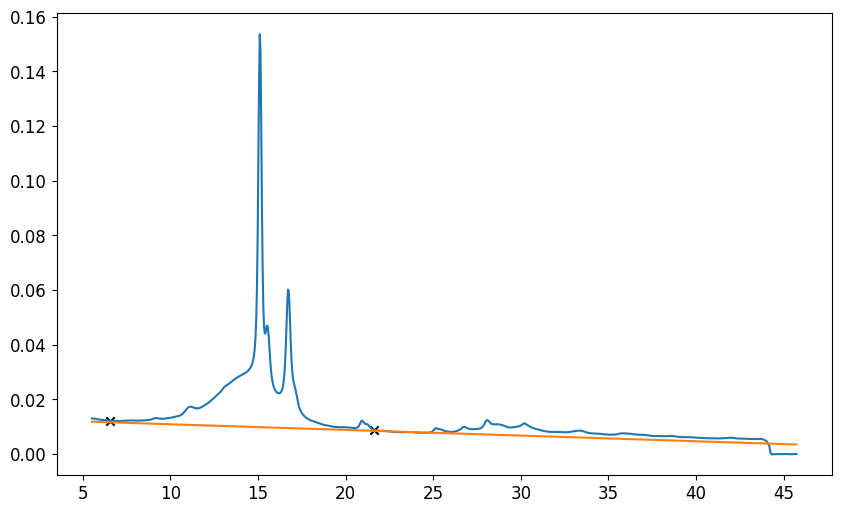

In [161]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00108_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.95

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

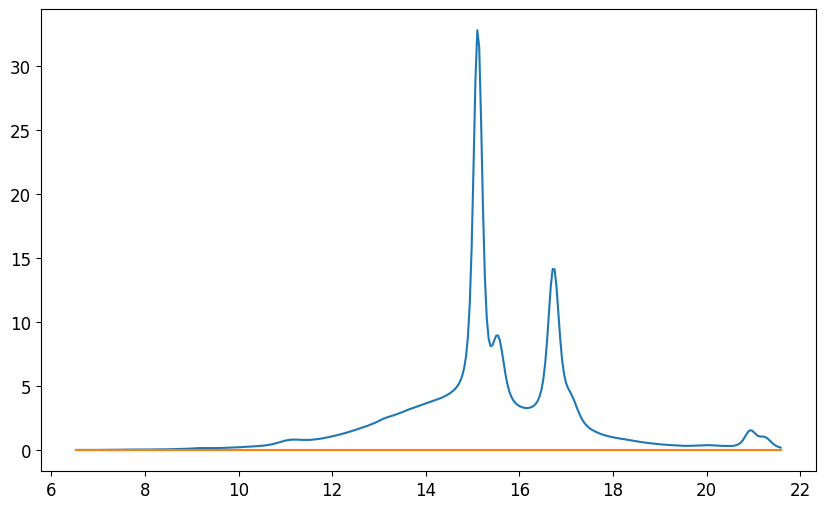

In [163]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M4 = X
Y_M4 = Y * X ** 2

In [164]:
build_M4 = PeakBuilder(X_M4, Y_M4)

In [165]:
Cr_M4 = 48.36

# Others

'PCL_M3_100ms_1m_1'

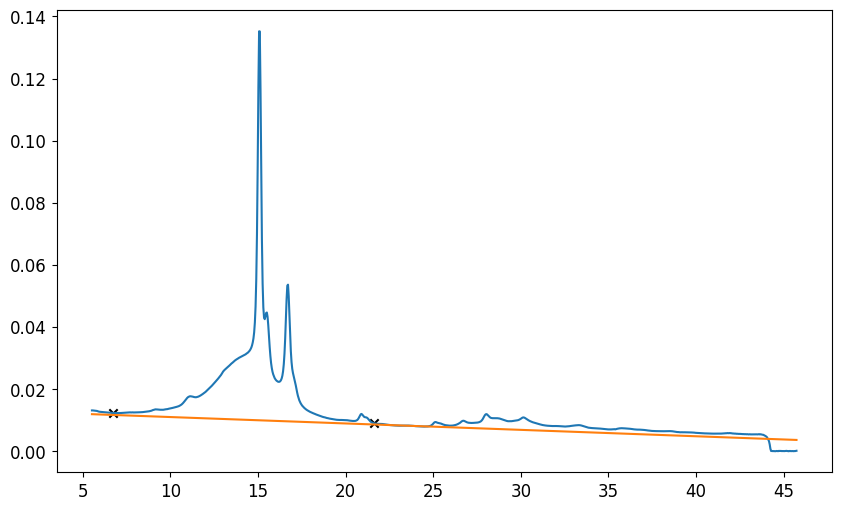

In [173]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00090_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 30
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.95

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

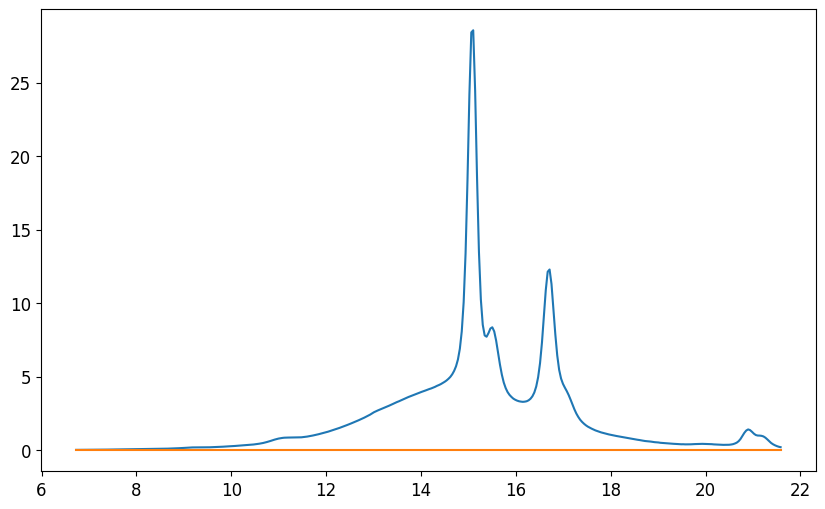

In [174]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3 = X
Y_M3 = Y * X ** 2

In [177]:
# Создаем новый билдер
build_M3 = PeakBuilder(X_M3, Y_M3)
build_M3.peaks = []

# Копируем все пики из build_M4 (сколько есть - столько и будет)
for peak in build_M4.peaks:
    build_M3.peaks.append([
        peak[0],  # x0
        peak[1],  # amp
        peak[2],  # sigma
        peak[3],  # type
        peak[4],  # gamma
        peak[5]   # crystalline
    ])

build_M3.update_peak_list()
build_M3.update_plot()

In [178]:
Cr_M3 = 42.81

## M2

'PCL_M2_100ms_1m_1'

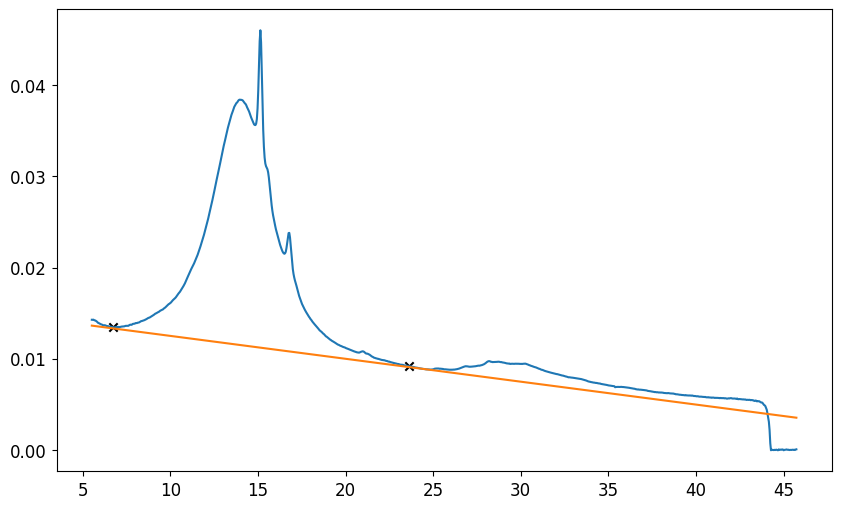

In [189]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00083_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 30
r = 450

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

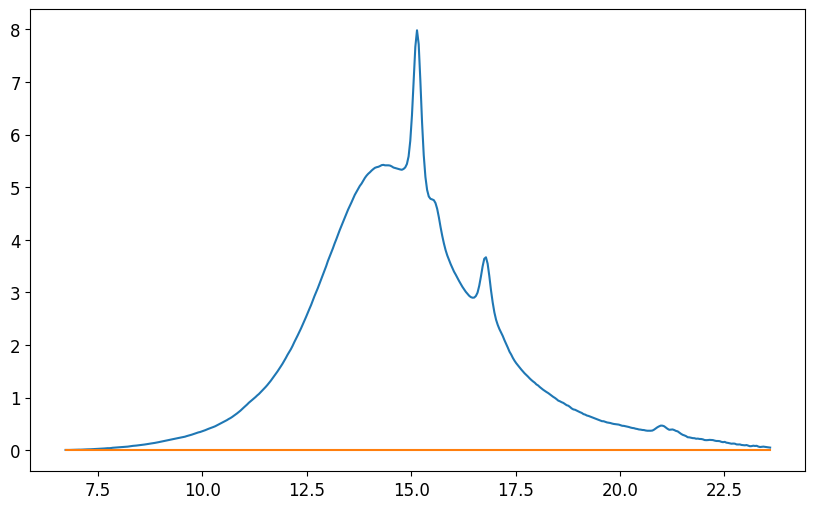

In [190]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M2 = X
Y_M2 = Y * X ** 2

In [193]:
# Создаем новый билдер
build_M2 = PeakBuilder(X_M2, Y_M2)

# Очищаем пики по умолчанию
build_M2.peaks = []

# Копируем пики из build_M4 (только то, что есть)
for peak in build_M4.peaks:
    build_M2.peaks.append([
        peak[0],  # x0
        peak[1],  # amp
        peak[2],  # sigma
        peak[3],  # type
        peak[4],  # gamma
        peak[5]   # crystalline
    ])

# Обновляем отображение
build_M2.update_peak_list()
build_M2.update_plot()